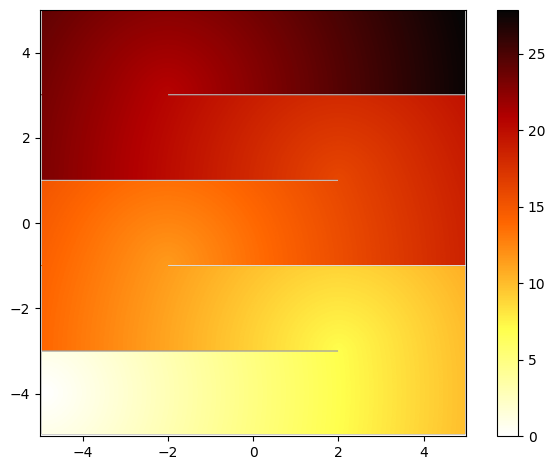

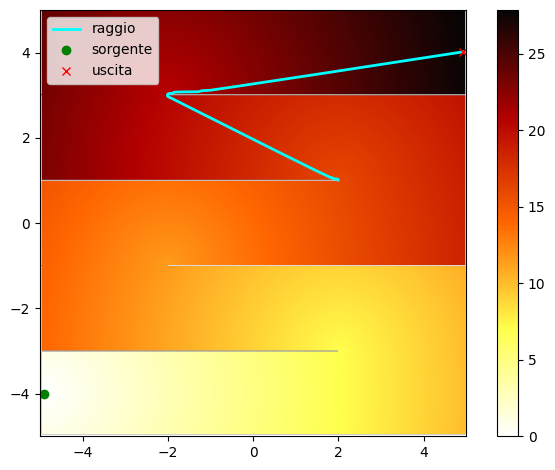

F e F_safe coincidono sui muri veri? True
tempo raggio: 12.251947377591973


In [ ]:
# ==============================================================================
# --FIM CON GODUNOV 1 + RAGGI CON INTERP. SPLINE GLOBALE SU LABIRINTO 500X500 --
# ==============================================================================

"""
Il seguente codice utilizza il metodo del FIM classico (v2) con l'aggiornamento
di Godunov del 2° ordine (quello a 4 punti) per generare la soluzione T_final su
cui poi è stato integrato il raggio tramite il metodo di Rounge-Kutta del 4°ordine.
In questo codice il gradiente non viene discretizzato direttamente da T, ma si
utilizza un metodo spline globale, come quello presentato sul Numerical Recepies,
attraverso il quale il gradiente non viene mai realmente discretizzato, ma è lo
stesso metodo a restituire le ∂T/∂x e ∂T/∂y.
"""

#------------------  LIBRERIE --------------------------------------------------

from typing import Text
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt
from scipy.ndimage import binary_dilation
from scipy.interpolate import RectBivariateSpline

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

nx = 500
ny = 500
nRows = 500
nCols = 500
sidex = 5
sidey = 5
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6

ix0 = 5
iy0 = 50

#------------------  CAMPO DI VELOCITA' (LABIRINTO) ----------------------------

F = np.ones(X.shape)
F_oncart = RegularGridInterpolator((X[0, :], Y[:, 0]), F.T, method='linear', bounds_error=False, fill_value=None)

F = 1 * np.ones(X.shape)

# pareti del bordo
F[:, 1]   = np.inf   # parete sinistra
F[:, 498] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[498, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[99, :]       = np.inf
F[99, 349:498] = 1   # apertura: colonne 350-498 in MATLAB → 349:498 in Python

# secondo muro orizzontale (riga 200, con apertura a destra)
F[199, :]      = np.inf
F[199, 1:150]  = 1   # apertura: colonne 2-150 in MATLAB → 1:150 in Python

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[299, :]       = np.inf
F[299, 349:498] = 1

# quarto muro orizzontale (riga 400, con apertura a destra)
F[399, :]      = np.inf
F[399, 1:150]  = 1

wall_mask = np.isinf(F)

#------------------  FASCIA DI SICUREZZA MURI ----------------------------------

def inflate_walls_smooth(F, wall_mask, margin_cells, penalty_factor):
    F_smooth = F.copy()
    dist_to_wall = distance_transform_edt(~wall_mask)   # distanza in celle dal muro più vicino
    ramp = np.clip(dist_to_wall / margin_cells, 0.0, 1.0)
    F_ramped = penalty_factor + (1.0 - penalty_factor) * ramp
    F_smooth[~wall_mask] = F_ramped[~wall_mask]
    return F_smooth

F_safe = inflate_walls_smooth(F, wall_mask, margin_cells=6, penalty_factor=0.3)

# ==============================================================================
# CALCOLO FIM
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0

active = np.zeros(T.shape, dtype=bool)

for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True

T_old = np.full(T.shape, np.inf)
continua = True
h = dx

#------------------ GODUNOV 2 --------------------------------------------------

def _dir_contribution(u0, u_n1, u_n2, valid1, valid2, alpha, alpha_prime):

    use = valid1 & (u0 > u_n1)

    second_ok = use & valid2 & (u_n2 < u_n1)
    first_ok  = use & ~second_ok

    t_prime = (4.0 * u_n1 - u_n2) / 3.0
    beta2   = -2.0 * alpha_prime * t_prime
    gamma2  = alpha_prime * (t_prime ** 2)

    beta1  = -(2.0 * u_n1 * alpha)
    gamma1 = (u_n1 ** 2) * alpha

    a_c = np.where(second_ok, alpha_prime, np.where(first_ok, alpha, 0.0))
    b_c = np.where(second_ok, beta2,       np.where(first_ok, beta1, 0.0))
    c_c = np.where(second_ok, gamma2,      np.where(first_ok, gamma1, 0.0))

    return a_c, b_c, c_c

def Godunov_update_2nd(T, F, row, col):

    u0 = T[row, col]

    def neighbor(rr, cc, axis_len_r=nRows, axis_len_c=nCols):
        rr_c = np.clip(rr, 0, axis_len_r - 1)
        cc_c = np.clip(cc, 0, axis_len_c - 1)
        return rr_c, cc_c

    # --- direzione riga meno (i-1, i-2) ---
    r_m1, r_m2 = row - 1, row - 2
    rc1, _ = neighbor(r_m1, col)
    rc2, _ = neighbor(r_m2, col)
    valid_m1 = (r_m1 >= 0) & ~wall_mask[rc1, col]
    valid_m2 = valid_m1 & (r_m2 >= 0) & ~wall_mask[rc2, col]
    u_rm1, u_rm2 = T[rc1, col], T[rc2, col]

    # --- direzione riga più (i+1, i+2) ---
    r_p1, r_p2 = row + 1, row + 2
    rc1, _ = neighbor(r_p1, col)
    rc2, _ = neighbor(r_p2, col)
    valid_p1 = (r_p1 < nRows) & ~wall_mask[rc1, col]
    valid_p2 = valid_p1 & (r_p2 < nRows) & ~wall_mask[rc2, col]
    u_rp1, u_rp2 = T[rc1, col], T[rc2, col]

    # --- direzione colonna meno (j-1, j-2) ---
    c_m1, c_m2 = col - 1, col - 2
    _, cc1 = neighbor(row, c_m1)
    _, cc2 = neighbor(row, c_m2)
    valid_cm1 = (c_m1 >= 0) & ~wall_mask[row, cc1]
    valid_cm2 = valid_cm1 & (c_m2 >= 0) & ~wall_mask[row, cc2]
    u_cm1, u_cm2 = T[row, cc1], T[row, cc2]

    # --- direzione colonna più (j+1, j+2) ---
    c_p1, c_p2 = col + 1, col + 2
    _, cc1 = neighbor(row, c_p1)
    _, cc2 = neighbor(row, c_p2)
    valid_cp1 = (c_p1 < nCols) & ~wall_mask[row, cc1]
    valid_cp2 = valid_cp1 & (c_p2 < nCols) & ~wall_mask[row, cc2]
    u_cp1, u_cp2 = T[row, cc1], T[row, cc2]

    alpha       = 1.0 / (h ** 2)
    alpha_prime = 9.0 / (4.0 * h ** 2)

    a = np.zeros_like(u0)
    b = np.zeros_like(u0)
    c = -(F[row, col] ** 2) * np.ones_like(u0)

    for u_n1, u_n2, v1, v2 in [
        (u_rm1, u_rm2, valid_m1, valid_m2),
        (u_rp1, u_rp2, valid_p1, valid_p2),
        (u_cm1, u_cm2, valid_cm1, valid_cm2),
        (u_cp1, u_cp2, valid_cp1, valid_cp2),
    ]:
        a_c, b_c, c_c = _dir_contribution(u0, u_n1, u_n2, v1, v2, alpha, alpha_prime)
        a += a_c
        b += b_c
        c += c_c

    disc = b ** 2 - 4.0 * a * c

    safe_a = np.where(a == 0, 1.0, a)          # evita divisione per zero
    u_quad = (-b + np.sqrt(np.maximum(disc, 0.0))) / (2.0 * safe_a)
    u_lin  = -b / (2.0 * safe_a)               # ramo "not isreal" del MATLAB

    u_new = np.where(disc >= 0, u_quad, u_lin)
    u_new = np.where(a == 0, u0, u_new)        # nessun vicino valido: resta invariato

    return np.minimum(u0, u_new)

#------------------  AGGIORNAMENTO FIM -----------------------------------------

def FIM(T, F, active):

    while np.any(active):

        row, col = np.where(active)
        p = T[row, col]
        q = Godunov_update(T, F, row, col)

        T[row, col] = q             # ← aggiorna T PRIMA del controllo convergenza

        converged_cond = np.abs(p - q) < eps
        conv_row, conv_col = row[converged_cond], col[converged_cond]

        active[conv_row, conv_col] = False

        for r, c in [(0, -1), (0, 1), (-1, 0), (1, 0)]:
            nb_row = conv_row + r
            nb_col = conv_col + c

            valid = (nb_row >= 0) & (nb_row < nRows) & (nb_col >= 0) & (nb_col < nCols)
            nb_row, nb_col = nb_row[valid], nb_col[valid]

            not_active = ~active[nb_row, nb_col]

            wall = np.isinf(F_safe[nb_row, nb_col])

            nb_row = nb_row[~wall]
            nb_col = nb_col[~wall]

            if nb_row.size == 0:
                continue

            p2 = T[nb_row, nb_col]
            q2 = Godunov_update(T, F, nb_row, nb_col)

            improve = q2 < p2
            nb_row, nb_col, q2 = nb_row[improve], nb_col[improve], q2[improve]

            T[nb_row, nb_col] = q2
            active[nb_row, nb_col] = True

    return T


T_final = FIM(T, F, active)


# Plot
fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)

plt.tight_layout()
plt.show()

# ==============================================================================
# CALCOLO RAGGI CON INTERPOLAZIONE SPLINE GLOBALE
# ==============================================================================

#---------------  METODO SPLINE GLOBALE RECTBIVARIATESPLINE --------------------

wall_mask = np.isinf(F)
unreached_mask = np.isinf(T_final) & ~wall_mask   # celle libere ma mai raggiunte
bad_mask = wall_mask | unreached_mask             # tutto ciò che va riempito

idx = distance_transform_edt(bad_mask, return_distances=False, return_indices=True)
T_filled = T_final.copy()
T_filled[bad_mask] = T_final[tuple(idx)][bad_mask]


# --- Fit dello spline bicubico direttamente su T (non sul gradiente!) ---
# RectBivariateSpline vuole gli assi in ordine crescente: x (colonne), y (righe)
spline_T = RectBivariateSpline(y, x, T_filled, kx=3, ky=3, s=0)

#------------------  FUNZIONE MURI ---------------------------------------------

def is_wall_at(pt, F, x, y):
    col = np.clip(np.searchsorted(x, pt[0]) - 1, 0, F.shape[1]-1)
    row = np.clip(np.searchsorted(y, pt[1]) - 1, 0, F.shape[0]-1)
    return np.isinf(F[row, col])

#------------------  NORMALIZZAZIONE DEL GRADIENTE -----------------------------

def grad_at_spline(pt, spline_T):
    px, py = pt
    gx = spline_T.ev(py, px, dx=0, dy=1)
    gy = spline_T.ev(py, px, dx=1, dy=0)
    if not (np.isfinite(gx) and np.isfinite(gy)):
        return np.array([0.0, 0.0])
    norm = np.sqrt(gx**2 + gy**2)
    if norm < 1e-12:
        return np.array([0.0, 0.0])
    scale = 1.0 / norm   # forza |grad T| = 1 (coerente con F=1 fuori dai muri)
    return np.array([gx * scale, gy * scale])

#------------------  RUNGE-KUTTA 4°ORDINE --------------------------------------

def trace_ray_rk4(start_pt, spline_T, source_pt, ds, max_steps, F, x, y):
    pt = np.array(start_pt, dtype=float)
    ray = [pt.copy()]

    for step in range(max_steps):

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        k1 = -grad_at_spline(pt, spline_T)
        if np.linalg.norm(k1) < 1e-12:
            break
        k2 = -grad_at_spline(pt + 0.5*ds*k1, spline_T)
        k3 = -grad_at_spline(pt + 0.5*ds*k2, spline_T)
        k4 = -grad_at_spline(pt + ds*k3, spline_T)

        dpt = (k1 + 2*k2 + 2*k3 + k4) / 6.0

        step_ds = ds
        pt_new = pt + step_ds * dpt
        n_tries = 0
        while is_wall_at(pt_new, F, x, y) and n_tries < 8:
            step_ds *= 0.5
            pt_new = pt + step_ds * dpt
            n_tries += 1

        if is_wall_at(pt_new, F, x, y):
            break

        ray.append(pt_new.copy())

        if np.linalg.norm(pt_new - np.array(source_pt)) < ds:
            ray.append(np.array(source_pt, dtype=float))
            break

        if step > 1 and np.linalg.norm(ray[-1] - ray[-2]) < 1e-8:
            break

        pt = pt_new

    return np.array(ray)

#------------------  CHIAMATA RAGGIO -------------------------------------------

ds = dx  # passo di integrazione, puoi anche provare dx/2 per più precisione
# coordinate cartesiane del punto sorgente
source_pt = (x[ix0], y[iy0])
# coordinate cartesiane del punto sorgente (coerenti con ix0, iy0)
source_line = (source_pt[0], source_pt[1] - ds, source_pt[1] + ds)

ix0_exit = 495
iy0_exit = 450
# punto d'uscita in alto a destra del dominio (esempio: vicino all'angolo)
exit_pt = (x[ix0_exit], y[iy0_exit])   # scegli tu la cella esatta, deve essere F finito lì

max_steps = 5000

ray = trace_ray_rk4(exit_pt, spline_T, source_pt, ds, max_steps, F, x, y)

#------------------  PLOT RAGGIO -----------------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)

ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=2, label='raggio')
ax.plot(*source_pt, 'go', label='sorgente')
ax.plot(*exit_pt, 'rx', label='uscita')
ax.legend()
plt.tight_layout()
plt.show()

print("F e F_safe coincidono sui muri veri?", np.array_equal(np.isinf(F), np.isinf(F_safe)))


def tempo_lungo_raggio(ray, F, x, y):
    """Integra il tempo di percorrenza sommando dl/F per ogni segmento del raggio."""
    tempo_tot = 0.0
    for i in range(len(ray) - 1):
        p0, p1 = ray[i], ray[i+1]
        dl = np.linalg.norm(p1 - p0)          # lunghezza del segmento
        mid = (p0 + p1) / 2                   # punto medio, per campionare F
        col = np.clip(np.searchsorted(x, mid[0]) - 1, 0, F.shape[1]-1)
        row = np.clip(np.searchsorted(y, mid[1]) - 1, 0, F.shape[0]-1)
        f_local = F[row, col]
        if np.isinf(f_local):
            f_local = 1e-6   # workaround: evita divisione per inf se il segmento tocca un muro
        tempo_tot += dl / f_local
    return tempo_tot

tempo_ray_spline = tempo_lungo_raggio(ray, F_safe, x, y)

print("tempo raggio:", tempo_ray_spline)
